# Cohort Analysis

## Objective

Analyze **monthly customer retention after acquisition** by grouping customers according to the month of their first purchase and tracking the percentage of each cohort that remains active in later months.

### Key definitions

- **Cohort:** A group of customers who made their first-ever purchase in the same month.
- **Cohort Month:** The customer's first-purchase month.
- **Cohort Index:** The number of calendar months between the cohort month and a particular purchase month.
- **M0:** Acquisition month. Retention is 100% by definition.
- **M1–M12:** Monthly customer activity from one to twelve calendar months after acquisition.
- **Retention Rate:** Unique active customers in a cohort month-index ÷ original cohort size.

> A customer is counted only once within a cohort-index even if they place multiple orders during that month.


## 1. Import Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## 2. Load Orders Data

The complete orders dataset is loaded first. Only the fields required for cohort analysis are then copied into a separate working DataFrame.


In [2]:
df = pd.read_csv(
    r"C:\Users\dhawa\Desktop\Vovers-Analytics\02_Database\Dataset\10_Orders.csv"
)

ot = df[['order_id', 'customer_id', 'order_datetime']].copy()

ot.head()


,order_id,customer_id,order_datetime
0,1,84045,2016-05-24 05:48:36
1,2,72538,2016-05-24 07:08:40
2,3,53182,2016-05-24 11:32:23
3,4,64789,2016-05-24 16:49:24
4,5,64789,2016-05-24 17:19:43


## 3. Data Validation

Before creating cohorts, validate the fields that directly affect customer and time-based calculations.

Checks performed:

- Missing customer IDs
- Missing order dates
- Duplicate order IDs
- Dataset date coverage
- Datatypes and dimensions


In [3]:
ot['order_datetime'] = pd.to_datetime(ot['order_datetime'])

validation_summary = pd.Series({
    'Rows': ot.shape[0],
    'Columns': ot.shape[1],
    'Duplicate Order IDs': ot['order_id'].duplicated().sum(),
    'Missing Customer IDs': ot['customer_id'].isna().sum(),
    'Missing Order Dates': ot['order_datetime'].isna().sum(),
    'Earliest Order': ot['order_datetime'].min(),
    'Latest Order': ot['order_datetime'].max()
})

validation_summary


Rows                                 125000
Columns                                   3
Duplicate Order IDs                       0
Missing Customer IDs                      0
Missing Order Dates                       0
Earliest Order          2016-05-24 05:48:36
Latest Order            2026-07-25 23:21:17
dtype: object

## 4. Create Order Month

Cohort analysis is performed at **monthly granularity**, so each order timestamp is converted to a monthly Period.

Example: `2025-03-18 14:30:00` → `2025-03`


In [4]:
ot['order_month'] = ot['order_datetime'].dt.to_period('M')

ot.head()


,order_id,customer_id,order_datetime,order_month
0,1,84045,2016-05-24 05:48:36,2016-05
1,2,72538,2016-05-24 07:08:40,2016-05
2,3,53182,2016-05-24 11:32:23,2016-05
3,4,64789,2016-05-24 16:49:24,2016-05
4,5,64789,2016-05-24 17:19:43,2016-05


## 5. Assign Cohort Month

Each customer is assigned to the month of their **first-ever purchase**.

`transform('min')` is used because it calculates each customer's earliest order month and broadcasts that value back to every order row belonging to the same customer.


In [5]:
ot['cohort_month'] = (
    ot.groupby('customer_id')['order_month']
      .transform('min')
)

ot.head()


,order_id,customer_id,order_datetime,order_month,cohort_month
0,1,84045,2016-05-24 05:48:36,2016-05,2016-05
1,2,72538,2016-05-24 07:08:40,2016-05,2016-05
2,3,53182,2016-05-24 11:32:23,2016-05,2016-05
3,4,64789,2016-05-24 16:49:24,2016-05,2016-05
4,5,64789,2016-05-24 17:19:43,2016-05,2016-05


## 6. Calculate Cohort Index

The cohort index measures how many calendar months after acquisition a purchase occurred.

For example, if a customer's cohort month is `2025-01`:

- Purchase in `2025-01` → M0
- Purchase in `2025-02` → M1
- Purchase in `2025-03` → M2

This is **monthly activity retention**, not an order-sequence measure. A customer can skip one month and become active again in a later month.


In [6]:
ot['cohort_index'] = (
    (ot['order_month'].dt.year - ot['cohort_month'].dt.year) * 12
    + (ot['order_month'].dt.month - ot['cohort_month'].dt.month)
)

ot.head()


,order_id,customer_id,order_datetime,order_month,cohort_month,cohort_index
0,1,84045,2016-05-24 05:48:36,2016-05,2016-05,0
1,2,72538,2016-05-24 07:08:40,2016-05,2016-05,0
2,3,53182,2016-05-24 11:32:23,2016-05,2016-05,0
3,4,64789,2016-05-24 16:49:24,2016-05,2016-05,0
4,5,64789,2016-05-24 17:19:43,2016-05,2016-05,0


## 7. Count Unique Active Customers

For every combination of cohort month and cohort index, count the number of **distinct customers** who purchased.

`nunique()` is necessary because one customer may place multiple orders in the same month but should count as only one active customer for retention analysis.


In [7]:
month_wise_cohort_count = (
    ot.groupby(['cohort_month', 'cohort_index'])['customer_id']
      .nunique()
)

month_wise_cohort_count.head(10)


cohort_month  cohort_index
2016-05       0               22
              1               11
              2                7
              3                2
              4                3
              5                2
              6                1
              8                2
              10               1
              11               1
Name: customer_id, dtype: int64

## 8. Build the Cohort Customer Matrix

The grouped Series is reshaped so that:

- Rows = acquisition cohorts
- Columns = cohort indices
- Values = unique active customers

### Reporting window

The final analysis uses **36 fully matured monthly cohorts** and follows each one through **M0–M12**.

The orders dataset currently ends on **25 July 2026**. Because July 2026 is only a partial month, the latest cohort with twelve **fully completed** post-acquisition months is **June 2025**.

Therefore, the reporting period is:

**July 2022 to June 2025** → 36 cohorts

For these mature cohorts, a missing cohort-index value means no customer was active in that observed month, so it is correctly replaced with `0`.


In [8]:
cohort_customer_matrix_all = month_wise_cohort_count.unstack()

cohort_customer_matrix = (
    cohort_customer_matrix_all
    .loc['2022-07':'2025-06', 0:12]
    .fillna(0)
)

cohort_customer_matrix.columns = [
    'M0', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6',
    'M7', 'M8', 'M9', 'M10', 'M11', 'M12'
]

cohort_customer_matrix


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
cohort_month,,,,,,,,,,,,,
2022-07,901.0,16.0,16.0,18.0,12.0,13.0,13.0,10.0,4.0,4.0,11.0,8.0,11.0
2022-08,844.0,8.0,23.0,15.0,15.0,4.0,7.0,12.0,7.0,6.0,9.0,10.0,9.0
2022-09,1066.0,23.0,21.0,19.0,9.0,11.0,10.0,12.0,3.0,4.0,11.0,6.0,11.0
2022-10,1494.0,37.0,19.0,18.0,18.0,15.0,24.0,19.0,17.0,12.0,16.0,13.0,16.0
2022-11,1539.0,15.0,18.0,11.0,14.0,15.0,19.0,19.0,18.0,15.0,10.0,31.0,29.0
2022-12,992.0,17.0,11.0,13.0,8.0,13.0,12.0,10.0,13.0,10.0,27.0,14.0,11.0
2023-01,1016.0,16.0,9.0,13.0,9.0,12.0,8.0,13.0,6.0,17.0,8.0,8.0,5.0
2023-02,965.0,11.0,17.0,13.0,9.0,10.0,13.0,6.0,15.0,11.0,16.0,6.0,6.0
2023-03,917.0,11.0,8.0,8.0,12.0,6.0,6.0,18.0,23.0,9.0,17.0,9.0,8.0


## 9. Calculate Cohort Retention Rates

Each row is divided by its own M0 customer count.

This converts the customer-count matrix into a retention-percentage matrix:

**Retention at Mx = Active customers at Mx ÷ Customers acquired at M0 × 100**


In [9]:
cohort_retention_matrix = (
    cohort_customer_matrix
    .div(cohort_customer_matrix['M0'], axis=0)
    .mul(100)
    .round(2)
)

cohort_retention_matrix


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
cohort_month,,,,,,,,,,,,,
2022-07,100.0,1.78,1.78,2.00,1.33,1.44,1.44,1.11,0.44,0.44,1.22,0.89,1.22
2022-08,100.0,0.95,2.73,1.78,1.78,0.47,0.83,1.42,0.83,0.71,1.07,1.18,1.07
2022-09,100.0,2.16,1.97,1.78,0.84,1.03,0.94,1.13,0.28,0.38,1.03,0.56,1.03
2022-10,100.0,2.48,1.27,1.20,1.20,1.00,1.61,1.27,1.14,0.80,1.07,0.87,1.07
2022-11,100.0,0.97,1.17,0.71,0.91,0.97,1.23,1.23,1.17,0.97,0.65,2.01,1.88
2022-12,100.0,1.71,1.11,1.31,0.81,1.31,1.21,1.01,1.31,1.01,2.72,1.41,1.11
2023-01,100.0,1.57,0.89,1.28,0.89,1.18,0.79,1.28,0.59,1.67,0.79,0.79,0.49
2023-02,100.0,1.14,1.76,1.35,0.93,1.04,1.35,0.62,1.55,1.14,1.66,0.62,0.62
2023-03,100.0,1.20,0.87,0.87,1.31,0.65,0.65,1.96,2.51,0.98,1.85,0.98,0.87


## 10. Validate the Retention Matrix

Every mature cohort must have **M0 = 100%** because M0 is the acquisition cohort compared with itself.


In [10]:
m0_validation = cohort_retention_matrix['M0'].eq(100).all()

print("All M0 retention values equal 100%:", m0_validation)
print("Retention matrix shape:", cohort_retention_matrix.shape)


All M0 retention values equal 100%: True
Retention matrix shape: (36, 13)


## 11. Average Retention by Months Since Acquisition

To summarize the overall retention pattern, calculate the mean retention rate across the 36 acquisition cohorts for each cohort index.

M0 is retained in the table for reference but excluded from the trend chart because its fixed 100% value would compress the much smaller post-acquisition retention rates.


In [11]:
average_retention = cohort_retention_matrix.mean(axis=0).round(2)

average_retention


M0     100.00
M1       1.18
M2       1.10
M3       1.06
M4       0.92
M5       0.93
M6       0.93
M7       0.90
M8       0.81
M9       0.78
M10      0.81
M11      0.86
M12      0.72
dtype: float64

## 12. Visualization — Average Post-Acquisition Retention

The line chart focuses on **M1–M12**.

It answers:

> On average, what percentage of customers from an acquisition cohort are active in each later calendar month?

### Important interpretation note

This is **monthly activity retention**. A customer does not need to purchase every month to appear in a later cohort index. For example, a customer may be inactive in M2 and purchase again in M3.


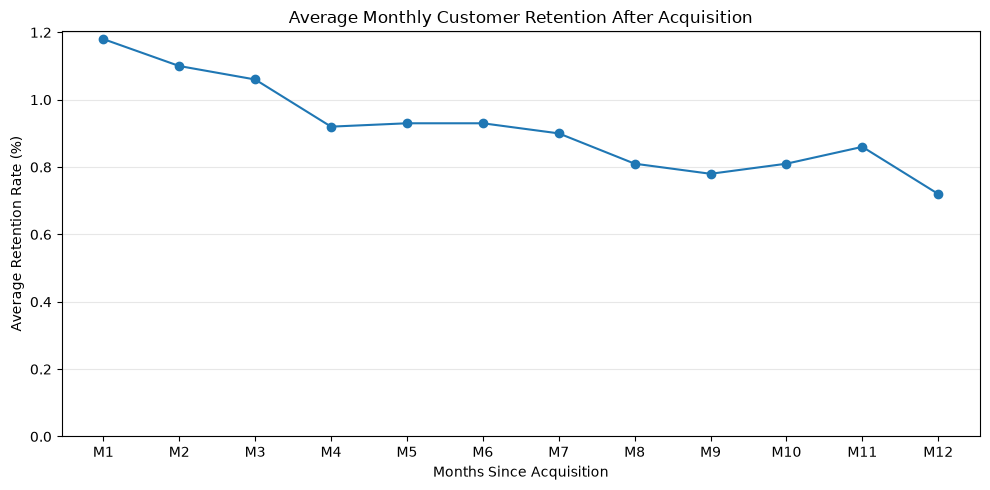

In [12]:
post_acquisition_retention = average_retention.iloc[1:]

plt.figure(figsize=(10, 5))
plt.plot(
    post_acquisition_retention.index,
    post_acquisition_retention.values,
    marker='o'
)

plt.xlabel("Months Since Acquisition")
plt.ylabel("Average Retention Rate (%)")
plt.title("Average Monthly Customer Retention After Acquisition")
plt.grid(axis='y', alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


## 13. Business Insights

Use the retention matrix and the M1–M12 trend to document only findings supported by the results.

Suggested questions:

- How much customer activity remains one month after acquisition?
- Does retention generally decline, stabilize, or fluctuate across M1–M12?
- Are there later-month recoveries that suggest customers return after skipping months?
- Is the observed pattern reasonable for a consumer-electronics retailer with naturally longer repurchase cycles?
- Are any individual acquisition cohorts materially stronger or weaker than the overall pattern?

> **Business insights to be finalized after reviewing the executed output.**


## 14. Analysis Notes & Limitations

- Cohorts are defined by **first-purchase month**, not registration month.
- Retention measures whether a customer was active in a specific later calendar month; it does not measure continuous survival.
- Multiple purchases by the same customer in one month count as one active customer.
- Only mature cohorts with a complete M0–M12 observation window are used for the final comparison.
- The dataset ends on 25 July 2026, so July 2026 is treated as a partial observation month. Therefore, June 2025 is the latest acquisition cohort included, ensuring that every selected cohort has a complete M0–M12 observation window.
- This analysis measures purchase activity only; it does not explain *why* customers return or fail to return.


## Conclusion

This cohort analysis provides a consistent view of customer purchasing activity during the first twelve months after acquisition. The retention matrix preserves cohort-level detail, while the average retention curve summarizes the overall post-acquisition pattern.

The next step is to convert the observed patterns into business insights and recommendations within the broader Customer Analysis engagement.
